In [1]:
pip install shap lime dice-ml alibi xgboost lightgbm catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of alibi to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of alibi to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 6.7 MB/s eta 0:00:00
  Created wheel for lime: filena

In [2]:
# ======================================================================
#   알츠하이머 XAI 임상 적용 실습 코드 (확장판 - 한글 폰트 에러 수정형)
# ======================================================================

import os

# ──────────────────────────────────────────────────────────────────────
# [0] 구글 코랩 한글 폰트 설치 및 환경 설정 (Matplotlib 폰트 에러 및 깨짐 해결)
# ──────────────────────────────────────────────────────────────────────
print("🔤 [0/9] 한글 폰트 설치 및 나눔고딕 설정 중...")
# 리눅스 시스템에 나눔 폰트 설치
os.system('apt-get -qq -y install fonts-nanum > /dev/null')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔 폰트 파일 경로
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# AttributeError 해결을 위한 최신 matplotlib 방식 적용 (폰트 등록)
fm.fontManager.addfont(font_path)

# 전역 폰트 설정 및 마이너스 깨짐 방지 적용
plt.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

# 나눔고딕이 정상 등록되었는지 확인 로그
print(f"✅ 한글 폰트 설정 완료: {plt.rcParams['font.family']}")

# ──────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.gridspec as gridspec
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

# 구글 코랩 파일 선택 인터페이스 라이브러리
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


🔤 [0/9] 한글 폰트 설치 및 나눔고딕 설정 중...
✅ 한글 폰트 설정 완료: ['NanumGothic']


In [3]:
# ======================================================================
# [1] 데이터 로드 및 전처리
# ======================================================================
print("\n" + "="*70)
print("  📦 [1/9] 데이터 로드 및 전처리")
print("="*70)

print("📂 [1/9] 알츠하이머 데이터셋(.csv) 업로드 단계")
print("아래 [파일 선택(Choose Files)] 버튼을 눌러 컴퓨터의 '2.alzheimers.csv' 파일을 선택해 주세요.")
print("-" * 65)

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print(f"\n✅ 파일이 성공적으로 업로드되었습니다: {file_name}")

df_raw = pd.read_csv(io.BytesIO(uploaded[file_name]))

# 불필요 컬럼 제거
drop_cols = ['PatientID', 'DoctorInCharge']
df = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns]).dropna()

target_col = 'Diagnosis'
df[target_col] = df[target_col].astype(int)

X = df.drop(columns=[target_col])
y = df[target_col]

# 이진 피처(0/1) 컬럼 목록 (DiCE 범주형 처리용)
binary_cols = [c for c in X.columns if X[c].nunique() == 2]
continuous_cols = [c for c in X.columns if c not in binary_cols]

# 8:2 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X.columns)

print(f"  - 전체 샘플 수 : {len(df):,}명  (정상: {(y==0).sum():,} / 알츠하이머: {(y==1).sum():,})")
print(f"  - 훈련 세트    : {X_train_scaled.shape}")
print(f"  - 테스트 세트  : {X_test_scaled.shape}")
print(f"  - 연속형 피처 : {len(continuous_cols)}개 / 이진형 피처 : {len(binary_cols)}개")




  📦 [1/9] 데이터 로드 및 전처리
📂 [1/9] 알츠하이머 데이터셋(.csv) 업로드 단계
아래 [파일 선택(Choose Files)] 버튼을 눌러 컴퓨터의 '2.alzheimers.csv' 파일을 선택해 주세요.
-----------------------------------------------------------------


Saving 2.alzheimers.csv to 2.alzheimers.csv

✅ 파일이 성공적으로 업로드되었습니다: 2.alzheimers.csv
  - 전체 샘플 수 : 2,149명  (정상: 1,389 / 알츠하이머: 760)
  - 훈련 세트    : (1719, 32)
  - 테스트 세트  : (430, 32)
  - 연속형 피처 : 17개 / 이진형 피처 : 15개


In [4]:
# ======================================================================
# [2] 멀티 모델 학습 및 최적 모델 선정
# ======================================================================
print("\n" + "="*70)
print("  🤖 [2/9] 다중 모델 학습 및 AUROC 기반 최적 모델 선정")
print("="*70)

models = {
    'RandomForest'    : RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost'         : XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM'        : LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost'        : CatBoostClassifier(random_state=42, verbose=0),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'AUROC'   : roc_auc_score(y_test, probs),
        'model'   : model,
    }
    print(f"  {name:<18}: Accuracy={results[name]['Accuracy']:.4f}  AUROC={results[name]['AUROC']:.4f}")

best_name  = max(results, key=lambda k: results[k]['AUROC'])
best_model = results[best_name]['model']
print(f"\n  🏆 선정된 최적 모델: {best_name}  (AUROC={results[best_name]['AUROC']:.4f})")



  🤖 [2/9] 다중 모델 학습 및 AUROC 기반 최적 모델 선정
  RandomForest      : Accuracy=0.9372  AUROC=0.9391
  GradientBoosting  : Accuracy=0.9465  AUROC=0.9464
  XGBoost           : Accuracy=0.9442  AUROC=0.9480
  LightGBM          : Accuracy=0.9535  AUROC=0.9527
  CatBoost          : Accuracy=0.9488  AUROC=0.9444

  🏆 선정된 최적 모델: LightGBM  (AUROC=0.9527)


In [5]:
# ======================================================================
# [3] 고위험군 샘플 선정 (테스트 세트에서 자동 탐색)
# ======================================================================
print("\n" + "="*70)
print("  🔍 [3/9] 테스트 세트에서 고위험 환자 선정")
print("="*70)

test_probs = best_model.predict_proba(X_test_scaled)[:, 1]
hi_risk_idx = np.where((test_probs > 0.80) & (y_test.values == 1))[0]
chosen_idx  = hi_risk_idx[0] if len(hi_risk_idx) > 0 else int(np.argmax(test_probs))

sample_scaled = X_test_scaled.iloc[[chosen_idx]]
sample_raw    = pd.Series(
    scaler.inverse_transform(sample_scaled)[0], index=X.columns
)
risk_pct = best_model.predict_proba(sample_scaled)[0][1] * 100

print(f"  - 선정된 테스트 인덱스 : {chosen_idx}")
print(f"  - 실제 진단 결과       : {'알츠하이머 환자 (Label=1)' if y_test.iloc[chosen_idx]==1 else '정상 (Label=0)'}")
print(f"  - AI 예측 발병 위험도  : {risk_pct:.2f}%")



  🔍 [3/9] 테스트 세트에서 고위험 환자 선정
  - 선정된 테스트 인덱스 : 0
  - 실제 진단 결과       : 알츠하이머 환자 (Label=1)
  - AI 예측 발병 위험도  : 99.84%



  🔮 [4/9] SHAP 분석  (LightGBM)


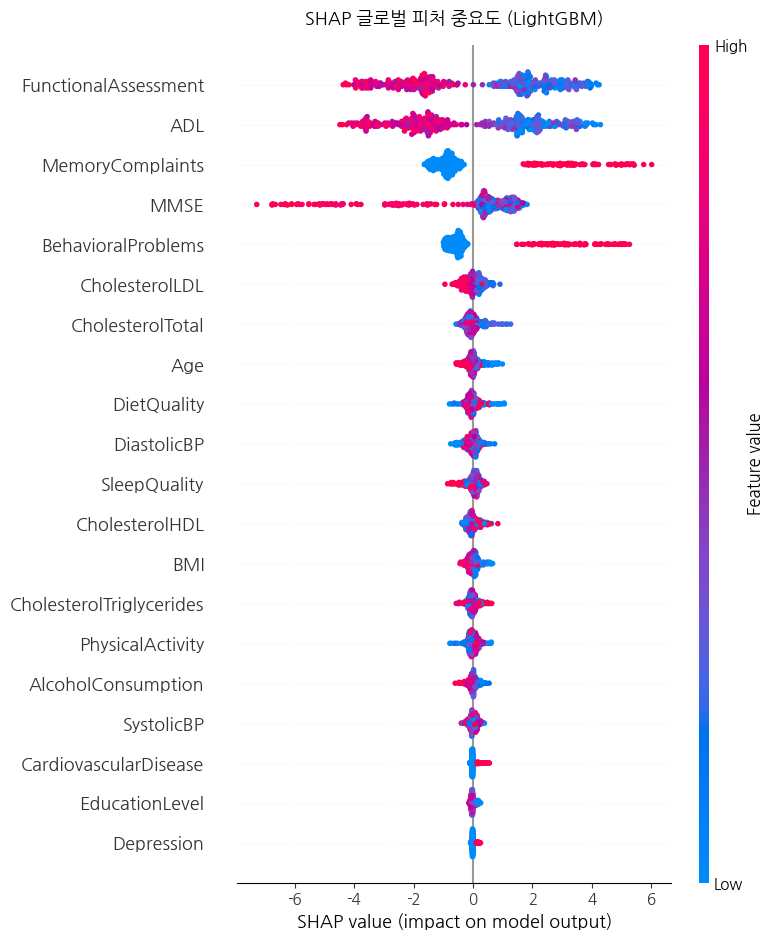

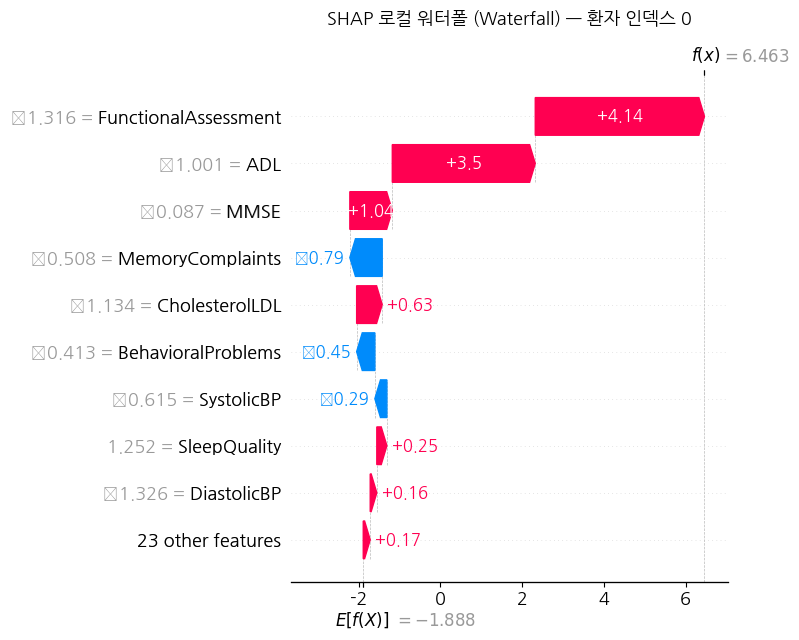

In [6]:
# ======================================================================
# [4] SHAP
# ======================================================================
print("\n" + "="*70)
print(f"  🔮 [4/9] SHAP 분석  ({best_name})")
print("="*70)
import shap

explainer_shap = shap.TreeExplainer(best_model)
shap_values_all = explainer_shap(X_test_scaled)

if len(shap_values_all.shape) == 3:
    sv_target = shap_values_all[:, :, 1]
else:
    sv_target = shap_values_all

# 글로벌 중요도 시각화
plt.figure(figsize=(10, 5))
plt.title(f"SHAP 글로벌 피처 중요도 ({best_name})", fontsize=13, fontweight='bold', pad=15)
shap.summary_plot(sv_target, X_test_scaled, show=False)
plt.tight_layout()
plt.savefig("shap_global.png", dpi=150, bbox_inches='tight')
plt.show()

# 로컬 Waterfall 시각화
plt.figure(figsize=(10, 4))
plt.title(f"SHAP 로컬 워터폴 (Waterfall) — 환자 인덱스 {chosen_idx}", fontsize=13, fontweight='bold', pad=15)
shap.plots.waterfall(sv_target[chosen_idx], show=False)
plt.tight_layout()
plt.savefig("shap_local.png", dpi=150, bbox_inches='tight')
plt.show()


  🍋 [5/9] LIME 분석  (LightGBM)


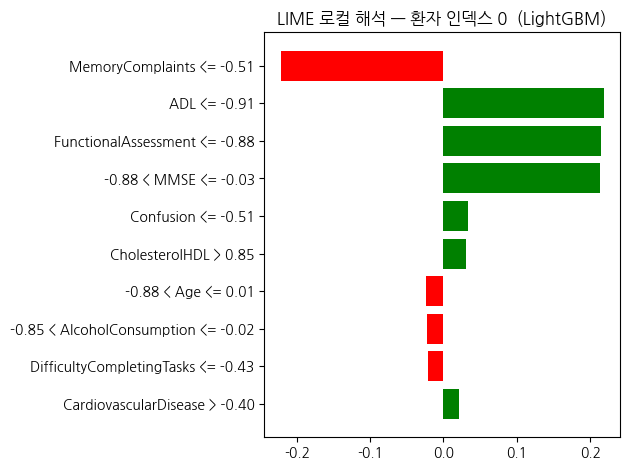

In [7]:
# ======================================================================
# [5] LIME
# ======================================================================
print("\n" + "="*70)
print(f"  🍋 [5/9] LIME 분석  ({best_name})")
print("="*70)
from lime.lime_tabular import LimeTabularExplainer

lime_exp = LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=list(X_train_scaled.columns),
    class_names=['Healthy', 'Alzheimers'],
    mode='classification',
    random_state=42,
)
exp_lime = lime_exp.explain_instance(
    data_row=sample_scaled.iloc[0].values,
    predict_fn=best_model.predict_proba,
    num_features=10,
)
fig = exp_lime.as_pyplot_figure()
plt.title(f"LIME 로컬 해석 — 환자 인덱스 {chosen_idx}  ({best_name})", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
# ======================================================================
# [6] DiCE (Counterfactual)
# ======================================================================
print("\n" + "="*70)
print(f"  🎲 [6/9] DiCE 반사실적 처방 생성  ({best_name})")
print("="*70)
import dice_ml

y_train_dice = y_train.reset_index(drop=True).astype(int)
dice_df = pd.concat([X_train_scaled.reset_index(drop=True), y_train_dice], axis=1)

d_data  = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=list(X_train_scaled.columns),
    outcome_name=target_col,
)
d_model = dice_ml.Model(model=best_model, backend="sklearn")
exp_dice = dice_ml.Dice(d_data, d_model, method="random")

cf = exp_dice.generate_counterfactuals(sample_scaled, total_CFs=3, desired_class=0)
print("  📋 현재 고위험 상태 → '정상' 판정을 위한 반사실적 시나리오 (변경된 값만 표시):")
cf.visualize_as_dataframe(show_only_changes=True)



  🎲 [6/9] DiCE 반사실적 처방 생성  (LightGBM)


100%|██████████| 1/1 [00:00<00:00,  2.47it/s]

  📋 현재 고위험 상태 → '정상' 판정을 위한 반사실적 시나리오 (변경된 값만 표시):
Query instance (original outcome : 1)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,-0.654552,0.990159,-0.703533,1.903666,1.5065,1.557017,-0.733214,-0.923802,0.775053,1.251721,...,-1.315852,-0.508349,-0.413498,-1.001428,-0.508349,-0.425962,-0.421186,-0.433561,1.506008,1



Diverse Counterfactual set (new outcome: 0)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,0.9323462931,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,0.0643299112,-,-,-,-,1.4182968,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,1.62432453,-,-,-,-,0.0


In [9]:
# ======================================================================
# [7] Anchors
# ======================================================================
print("\n" + "="*70)
print(f"  ⚓ [7/9] Anchors 규칙 추출  ({best_name})")
print("="*70)
from alibi.explainers import AnchorTabular

predict_fn_int = lambda x: best_model.predict(x).astype(int)
anchor_exp = AnchorTabular(
    predictor=predict_fn_int,
    feature_names=list(X_train_scaled.columns),
)
anchor_exp.fit(np.array(X_train_scaled))
anchor_result = anchor_exp.explain(np.array(sample_scaled)[0], threshold=0.95)
anchor_rules  = anchor_result.anchor
anchor_prec   = anchor_result.precision

print(f"  정밀도(Precision) : {anchor_prec:.3f}")
print(f"  커버리지(Coverage): {anchor_result.coverage:.3f}")
print("  [확진 핵심 조건]:")
for i, rule in enumerate(anchor_rules, 1):
    print(f"    조건 {i}: {rule}")



  ⚓ [7/9] Anchors 규칙 추출  (LightGBM)
  정밀도(Precision) : 0.983
  커버리지(Coverage): 0.750
  [확진 핵심 조건]:
    조건 1: FunctionalAssessment <= -0.88
    조건 2: ADL <= 0.02
    조건 3: MMSE <= 0.87


In [10]:
# ======================================================================
# [8] 표준 임상 리포트 (테스트셋 고위험 환자)
# ======================================================================
print("\n" + "="*70)
print(f"  🏥 [8/9] 임상 XAI 리포트 — 테스트 세트 고위험 환자 (idx {chosen_idx})")
print("="*70)

cf_df = cf.cf_examples_list[0].final_cfs_df
actionable = {
    'BMI'             : '체중 관리 (식단 조절 + 유산소 운동)',
    'PhysicalActivity': '주간 신체 활동량 증대 (유산소 30분/일)',
    'DietQuality'     : '식단 질 개선 (지중해식 식단 권장)',
    'SystolicBP'      : '수축기 혈압 관리 (염분 제한, 투약 검토)',
    'SleepQuality'    : '수면 환경 개선 (규칙적 수면 사이클 유도)',
    'AlcoholConsumption': '음주 감량',
    'MMSE'            : '인지 재활 훈련 (인지 자극 프로그램 도입)',
    'FunctionalAssessment': '일상 기능 회복 훈련',
}

print(f"\n  ▶ 환자 핵심 임상 지표")
key_cols = ['Age','BMI','MMSE','FunctionalAssessment','PhysicalActivity',
            'DietQuality','SystolicBP','SleepQuality','AlcoholConsumption']
for col in key_cols:
    if col in sample_raw:
        flag_str = ""
        if col == 'MMSE' and sample_raw[col] < 18:
            flag_str = " ⚠️ 중등도 인지저하"
        elif col == 'SystolicBP' and sample_raw[col] > 140:
            flag_str = " ⚠️ 고혈압 범위"
        print(f"    {col:<28}: {sample_raw[col]:.2f}{flag_str}")

print(f"\n  ▶ Anchors 확진 조건 (신뢰도 {anchor_prec*100:.1f}%)")
for i, rule in enumerate(anchor_rules, 1):
    print(f"    조건 {i}: {rule}")

print(f"\n  ▶ DiCE 기반 맞춤형 처방 목표")
if cf_df is not None and len(cf_df) > 0:
    cf_raw = pd.Series(
        scaler.inverse_transform(cf_df.drop(columns=[target_col]).iloc[[0]])[0],
        index=X.columns
    )
    rx_count = 0
    for feat, desc in actionable.items():
        if feat in X.columns:
            cur, tgt = sample_raw[feat], cf_raw[feat]
            if abs(cur - tgt) > 0.1:
                rx_count += 1
                direction = "↑ 상향" if tgt > cur else "↓ 하향"
                print(f"    [{rx_count}] {feat:<28}: {cur:.2f}  →  {tgt:.2f}  ({direction})  |  {desc}")
    if rx_count == 0:
        print("    - 가역적 위험인자가 미미. 약물 조기 개입 및 유전 상담 권장.")


  🏥 [8/9] 임상 XAI 리포트 — 테스트 세트 고위험 환자 (idx 0)

  ▶ 환자 핵심 임상 지표
    Age                         : 69.00
    BMI                         : 38.57
    MMSE                        : 13.96 ⚠️ 중등도 인지저하
    FunctionalAssessment        : 1.27
    PhysicalActivity            : 2.27
    DietQuality                 : 7.29
    SystolicBP                  : 118.00
    SleepQuality                : 9.26
    AlcoholConsumption          : 5.89

  ▶ Anchors 확진 조건 (신뢰도 98.3%)
    조건 1: FunctionalAssessment <= -0.88
    조건 2: ADL <= 0.02
    조건 3: MMSE <= 0.87

  ▶ DiCE 기반 맞춤형 처방 목표
    - 가역적 위험인자가 미미. 약물 조기 개입 및 유전 상담 권장.


In [11]:
# ======================================================================
# [9] ★ 사례 연구(Case Study): 합성 고위험 환자 "환자 A"
# ======================================================================
print("\n\n" + "█"*70)
print("  ★ [9/9]  사례 연구 (Clinical Case Study)  ★")
print("  가상 고위험 환자 '환자 A'에 대한 전 단계 XAI 임상 분석")
print("█"*70)

case_profile = {
    'Age'                      : 78,
    'Gender'                   : 0,
    'Ethnicity'                : 0,
    'EducationLevel'           : 1,
    'BMI'                      : 31.5,
    'Smoking'                  : 1,
    'AlcoholConsumption'       : 8.2,
    'PhysicalActivity'         : 1.2,
    'DietQuality'              : 2.1,
    'SleepQuality'             : 3.5,
    'FamilyHistoryAlzheimers'  : 1,
    'CardiovascularDisease'    : 1,
    'Diabetes'                 : 1,
    'Depression'               : 1,
    'HeadInjury'               : 0,
    'Hypertension'             : 1,
    'SystolicBP'               : 162,
    'DiastolicBP'              : 95,
    'CholesterolTotal'         : 245.0,
    'CholesterolLDL'           : 158.0,
    'CholesterolHDL'           : 38.0,
    'CholesterolTriglycerides' : 215.0,
    'MMSE'                     : 14.0,
    'FunctionalAssessment'     : 3.1,
    'MemoryComplaints'         : 1,
    'BehavioralProblems'       : 1,
    'ADL'                      : 2.8,
    'Confusion'                : 1,
    'Disorientation'           : 1,
    'PersonalityChanges'       : 1,
    'DifficultyCompletingTasks': 1,
    'Forgetfulness'            : 1,
}

case_df  = pd.DataFrame([case_profile])[X.columns]
case_scaled = pd.DataFrame(scaler.transform(case_df), columns=X.columns)




██████████████████████████████████████████████████████████████████████
  ★ [9/9]  사례 연구 (Clinical Case Study)  ★
  가상 고위험 환자 '환자 A'에 대한 전 단계 XAI 임상 분석
██████████████████████████████████████████████████████████████████████


In [12]:
# ────────────────────────────────────────────────────────────────────
#  9-2. 환자 A 예측 결과 출력
# ────────────────────────────────────────────────────────────────────
case_prob    = best_model.predict_proba(case_scaled)[0][1]
case_pred    = best_model.predict(case_scaled)[0]
case_label   = "🔴 알츠하이머 고위험 (양성)" if case_pred == 1 else "🟢 정상 (음성)"

print(f"\n  ┌─ 환자 A 기본 정보 {'─'*44}┐")
print(f"  │  나이: {case_profile['Age']}세  |  성별: {'여성' if case_profile['Gender']==0 else '남성'}  |  교육: {'초등 수준' if case_profile['EducationLevel']==1 else '기타'}")
print(f"  │  AI 예측 결과    : {case_label}")
print(f"  │  발병 위험 확률  : {case_prob*100:.1f}%")
print(f"  └{'─'*57}┘")


  ┌─ 환자 A 기본 정보 ────────────────────────────────────────────┐
  │  나이: 78세  |  성별: 여성  |  교육: 초등 수준
  │  AI 예측 결과    : 🔴 알츠하이머 고위험 (양성)
  │  발병 위험 확률  : 99.9%
  └─────────────────────────────────────────────────────────┘


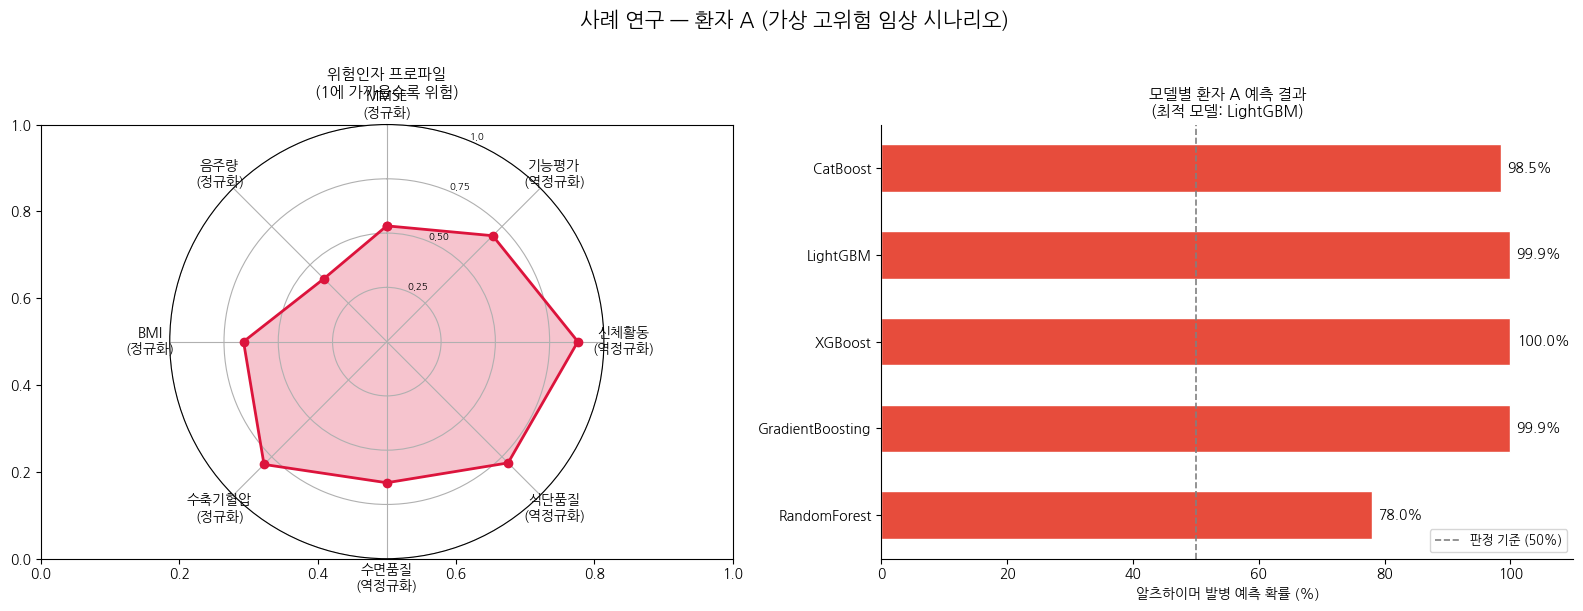

In [13]:
# ────────────────────────────────────────────────────────────────────
#  9-3. 시각화: 환자 A 임상 레이더 차트 (위험인자 프로파일)
# ────────────────────────────────────────────────────────────────────
radar_features = {
    'MMSE\n(정규화)'          : 1 - (case_profile['MMSE'] / 30),
    '기능평가\n(역정규화)'    : 1 - (case_profile['FunctionalAssessment'] / 10),
    '신체활동\n(역정규화)'    : 1 - (case_profile['PhysicalActivity'] / 10),
    '식단품질\n(역정규화)'    : 1 - (case_profile['DietQuality'] / 10),
    '수면품질\n(역정규화)'    : 1 - (case_profile['SleepQuality'] / 10),
    '수축기혈압\n(정규화)'    : (case_profile['SystolicBP'] - 90) / 90,
    'BMI\n(정규화)'           : (case_profile['BMI'] - 15) / 25,
    '음주량\n(정규화)'        : case_profile['AlcoholConsumption'] / 20,
}
r_labels = list(radar_features.keys())
r_values = list(radar_features.values())
r_values += r_values[:1]

angles = np.linspace(0, 2 * np.pi, len(r_labels), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("사례 연구 — 환자 A (가상 고위험 임상 시나리오)", fontsize=15, fontweight='bold', y=1.01)

# 레이더 차트 한글 폰트 연동
ax_r = plt.subplot(121, polar=True)
ax_r.set_theta_offset(np.pi / 2)
ax_r.set_theta_direction(-1)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(r_labels, size=9, fontproperties=fm.FontProperties(fname=font_path))
ax_r.set_ylim(0, 1)
ax_r.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_r.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], size=7)
ax_r.plot(angles, r_values, 'o-', linewidth=2, color='crimson')
ax_r.fill(angles, r_values, alpha=0.25, color='crimson')
ax_r.set_title("위험인자 프로파일\n(1에 가까울수록 위험)", size=11, fontweight='bold', pad=20)

# 모델별 예측 확률 막대그래프 한글 연동
model_names  = list(results.keys())
model_probs  = [results[n]['model'].predict_proba(case_scaled)[0][1] * 100 for n in model_names]
colors = ['#e74c3c' if p >= 50 else '#2ecc71' for p in model_probs]

ax_b = axes[1]
bars = ax_b.barh(model_names, model_probs, color=colors, edgecolor='white', height=0.55)
ax_b.axvline(50, color='gray', linestyle='--', linewidth=1.2, label='판정 기준 (50%)')
for bar, prob in zip(bars, model_probs):
    ax_b.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
              f'{prob:.1f}%', va='center', fontsize=10, fontweight='bold')
ax_b.set_xlim(0, 110)
ax_b.set_xlabel("알츠하이머 발병 예측 확률 (%)", fontsize=10)
ax_b.set_title(f"모델별 환자 A 예측 결과\n(최적 모델: {best_name})", fontsize=11, fontweight='bold')
ax_b.legend(fontsize=9)
ax_b.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("case_study_overview.png", dpi=150, bbox_inches='tight')
plt.show()


  ▶ 9-4. 환자 A SHAP 로컬 해석 (Waterfall Plot)


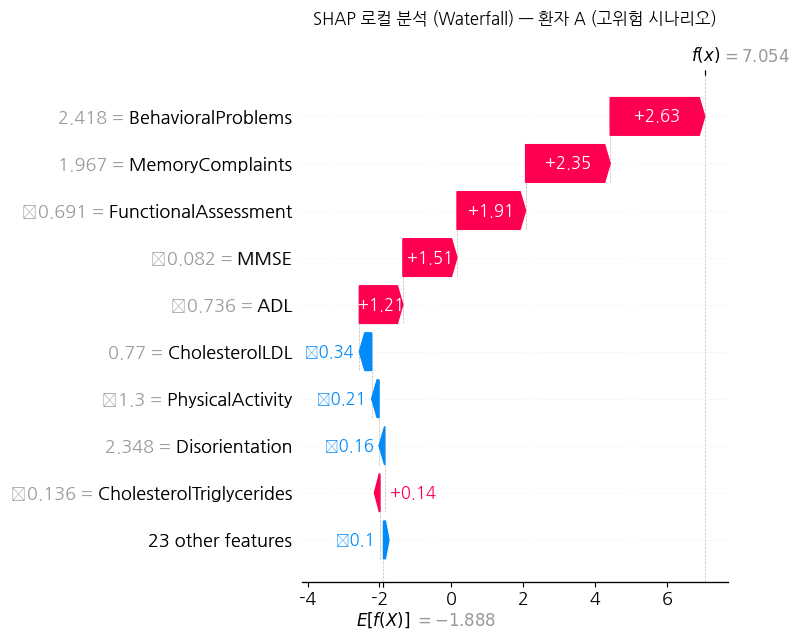

In [14]:
# ────────────────────────────────────────────────────────────────────
#  9-4. 환자 A — SHAP Waterfall (로컬 해석)
# ────────────────────────────────────────────────────────────────────
print("\n  ▶ 9-4. 환자 A SHAP 로컬 해석 (Waterfall Plot)")
case_shap = explainer_shap(case_scaled)
if len(case_shap.shape) == 3:
    case_shap_target = case_shap[:, :, 1]
else:
    case_shap_target = case_shap

plt.figure(figsize=(10, 5))
plt.title("SHAP 로컬 분석 (Waterfall) — 환자 A (고위험 시나리오)", fontsize=12, fontweight='bold', pad=15)
shap.plots.waterfall(case_shap_target[0], show=False)
plt.tight_layout()
plt.savefig("case_shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()


  ▶ 9-5. 환자 A LIME 로컬 해석


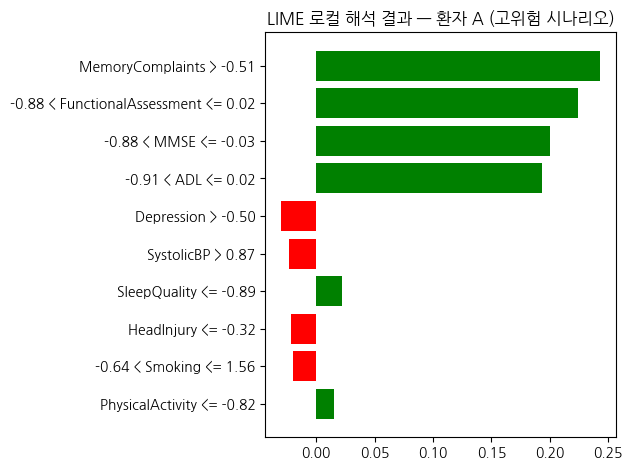

In [15]:
# ────────────────────────────────────────────────────────────────────
#  9-5. 환자 A — LIME (로컬 해석)
# ────────────────────────────────────────────────────────────────────
print("\n  ▶ 9-5. 환자 A LIME 로컬 해석")
exp_case_lime = lime_exp.explain_instance(
    data_row=case_scaled.iloc[0].values,
    predict_fn=best_model.predict_proba,
    num_features=10,
)
fig = exp_case_lime.as_pyplot_figure()
plt.title("LIME 로컬 해석 결과 — 환자 A (고위험 시나리오)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("case_lime.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ────────────────────────────────────────────────────────────────────
#  9-6. 환자 A — DiCE (반사실적 처방 3개)
# ────────────────────────────────────────────────────────────────────
print("\n  ▶ 9-6. 환자 A DiCE 반사실적 처방 (정상 판정 조건 탐색)")
cf_case = exp_dice.generate_counterfactuals(case_scaled, total_CFs=3, desired_class=0)
print("  [변경된 값만 표시 — 어떤 수치를 바꿔야 '정상' 판정을 받는가?]")
cf_case.visualize_as_dataframe(show_only_changes=True)



  ▶ 9-6. 환자 A DiCE 반사실적 처방 (정상 판정 조건 탐색)


100%|██████████| 1/1 [00:00<00:00,  2.52it/s]

  [변경된 값만 표시 — 어떤 수치를 바꿔야 '정상' 판정을 받는가?]
Query instance (original outcome : 1)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,0.343534,-1.009939,-0.703533,-0.317924,0.52805,1.557017,-0.331656,-1.300278,-1.007324,-2.006945,...,-0.690632,1.967152,2.418389,-0.736059,1.967152,2.347629,2.374251,2.306481,1.506008,1



Diverse Counterfactual set (new outcome: 0)


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,-,-,-,-,-,-,-,-0.88395057305,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0


In [17]:
# ────────────────────────────────────────────────────────────────────
#  9-7. 환자 A — Anchors 확진 규칙
# ────────────────────────────────────────────────────────────────────
print("\n  ▶ 9-7. 환자 A Anchors 확진 규칙 추출")
case_anchor = anchor_exp.explain(np.array(case_scaled)[0], threshold=0.95)
print(f"  정밀도   : {case_anchor.precision:.3f}")
print(f"  커버리지 : {case_anchor.coverage:.3f}")
print("  [확진 핵심 조건]:")
for i, rule in enumerate(case_anchor.anchor, 1):
    print(f"    조건 {i}: {rule}")



  ▶ 9-7. 환자 A Anchors 확진 규칙 추출
  정밀도   : 1.000
  커버리지 : 0.750
  [확진 핵심 조건]:
    조건 1: BehavioralProblems > -0.41
    조건 2: MemoryComplaints > -0.51
    조건 3: MMSE <= 0.87


In [18]:
# ────────────────────────────────────────────────────────────────────
#  9-8. 환자 A 종합 임상 리포트 출력
# ────────────────────────────────────────────────────────────────────
print("\n\n" + "="*70)
print("  📋 환자 A — 종합 임상 XAI 보고서")
print("  (AI 보조 진단 요약 / 의료진 참고용)")
print("="*70)

CRITICAL = "⚠️ "
OK       = "   "

def flag(val, thres_high=None, thres_low=None, high_bad=True):
    if high_bad:
        return CRITICAL if (thres_high and val > thres_high) else OK
    else:
        return CRITICAL if (thres_low and val < thres_low) else OK

print(f"""
  ┌─────────────────────────────────────────────────────────────────┐
  │   환자 A   |  78세, 여성  |  AI 진단: {case_label}
  │   발병 확률: {case_prob*100:.1f}%  ({best_name} 기준)
  └─────────────────────────────────────────────────────────────────┘

  ■ 주요 위험인자 현황
  ─────────────────────────────────────────────────────────────────
  {flag(case_profile['MMSE'], thres_low=18, high_bad=False)}MMSE 점수           : {case_profile['MMSE']:.0f}/30  (18↓ = 인지저하 경보)
  {CRITICAL}FunctionalAssessment  : {case_profile['FunctionalAssessment']:.1f}/10  (일상 기능 심각 저하)
  {flag(case_profile['SystolicBP'], thres_high=140)}수축기 혈압          : {case_profile['SystolicBP']} mmHg  (140↑ = 고혈압 범주)
  {flag(case_profile['BMI'], thres_high=30)}BMI                  : {case_profile['BMI']:.1f}  (30↑ = 비만)
  {flag(case_profile['PhysicalActivity'], thres_low=3, high_bad=False)}신체 활동량          : {case_profile['PhysicalActivity']:.1f}/10  (권장치 미달)
  {flag(case_profile['DietQuality'], thres_low=4, high_bad=False)}식단 품질            : {case_profile['DietQuality']:.1f}/10  (불량)
  {flag(case_profile['SleepQuality'], thres_low=5, high_bad=False)}수면 품질            : {case_profile['SleepQuality']:.1f}/10  (불량)
  {flag(case_profile['CholesterolLDL'], thres_high=130)}LDL 콜레스테롤       : {case_profile['CholesterolLDL']:.0f} mg/dL  (130↑ = 고위험)
  {flag(case_profile['CholesterolHDL'], thres_low=40, high_bad=False)}HDL 콜레스테롤       : {case_profile['CholesterolHDL']:.0f} mg/dL  (40↓ = 저위험)

  ■ 동반 질환 체크리스트 (복합 위험도)
  ─────────────────────────────────────────────────────────────────
  {CRITICAL}가족력 (알츠하이머)  : 있음
  {CRITICAL}심혈관 질환          : 있음
  {CRITICAL}고혈압               : 있음
  {CRITICAL}당뇨                 : 있음
  {CRITICAL}우울증               : 있음
  {CRITICAL}흡연                 : 흡연자

  ■ 임상 증상 체크리스트
  ─────────────────────────────────────────────────────────────────
  {CRITICAL}기억 불평 (Memory Complaints)      : 있음
  {CRITICAL}행동 이상 (Behavioral Problems)    : 있음
  {CRITICAL}혼란 (Confusion)                   : 있음
  {CRITICAL}지남력 장애 (Disorientation)       : 있음
  {CRITICAL}성격 변화 (Personality Changes)    : 있음
  {CRITICAL}과제 수행 장애                     : 있음
  {CRITICAL}건망증                             : 있음

  ■ Anchors 확진 패턴 (AI 모델이 진단 결론을 내리는 핵심 조건)
  ─────────────────────────────────────────────────────────────────""")

for i, rule in enumerate(case_anchor.anchor, 1):
    print(f"    조건 {i}: {rule}")





  📋 환자 A — 종합 임상 XAI 보고서
  (AI 보조 진단 요약 / 의료진 참고용)

  ┌─────────────────────────────────────────────────────────────────┐
  │   환자 A   |  78세, 여성  |  AI 진단: 🔴 알츠하이머 고위험 (양성)
  │   발병 확률: 99.9%  (LightGBM 기준)
  └─────────────────────────────────────────────────────────────────┘

  ■ 주요 위험인자 현황
  ─────────────────────────────────────────────────────────────────
  ⚠️ MMSE 점수           : 14/30  (18↓ = 인지저하 경보)
  ⚠️ FunctionalAssessment  : 3.1/10  (일상 기능 심각 저하)
  ⚠️ 수축기 혈압          : 162 mmHg  (140↑ = 고혈압 범주)
  ⚠️ BMI                  : 31.5  (30↑ = 비만)
  ⚠️ 신체 활동량          : 1.2/10  (권장치 미달)
  ⚠️ 식단 품질            : 2.1/10  (불량)
  ⚠️ 수면 품질            : 3.5/10  (불량)
  ⚠️ LDL 콜레스테롤       : 158 mg/dL  (130↑ = 고위험)
  ⚠️ HDL 콜레스테롤       : 38 mg/dL  (40↓ = 저위험)

  ■ 동반 질환 체크리스트 (복합 위험도)
  ─────────────────────────────────────────────────────────────────
  ⚠️ 가족력 (알츠하이머)  : 있음
  ⚠️ 심혈관 질환          : 있음
  ⚠️ 고혈압               : 있음
  ⚠️ 당뇨                 : 있음
  ⚠️ 우울증               : 있음
  ⚠️ 흡연  

In [19]:
# DiCE 처방 출력
print(f"""
  ■ 맞춤형 처방 목표 (DiCE 반사실적 분석)
  ─────────────────────────────────────────────────────────────────
  * AI 모델이 '정상' 판정을 내리려면 아래 수치들이 조정되어야 합니다.
  * 아래 목표치는 임상 의사의 최종 검토 및 처방을 필요로 합니다.""")

cf_case_df = cf_case.cf_examples_list[0].final_cfs_df
if cf_case_df is not None and len(cf_case_df) > 0:
    cf_case_raw = pd.Series(
        scaler.inverse_transform(cf_case_df.drop(columns=[target_col]).iloc[[0]])[0],
        index=X.columns,
    )
    prescription_map = {
        'MMSE'               : ('인지 재활 훈련 (인지자극 프로그램, 약물 검토)',          '점'),
        'FunctionalAssessment': ('일상 기능 회복 훈련 (작업치료, 보호자 교육)',            '점'),
        'PhysicalActivity'   : ('유산소 운동 프로그램 30분/일 처방',                       '점'),
        'DietQuality'        : ('영양사 연계 식단 관리 (지중해식 식단)',                    '점'),
        'SleepQuality'       : ('수면 클리닉 연계 (수면위생 교육, 필요 시 약물)',          '점'),
        'BMI'                : ('체중 감량 목표 설정 (칼로리 제한 + 운동 병행)',           'kg/m²'),
        'SystolicBP'         : ('혈압약 처방 검토, 저염 식이, 생활 습관 교정',             'mmHg'),
        'AlcoholConsumption' : ('금주/절주 상담, 알코올 의존 평가',                        '단위'),
        'CholesterolLDL'     : ('스타틴 계열 약물 처방 검토',                              'mg/dL'),
    }
    cnt = 0
    for feat, (desc, unit) in prescription_map.items():
        if feat in X.columns:
            cur = case_df.iloc[0][feat]
            tgt = cf_case_raw[feat]
            if abs(cur - tgt) > 0.1:
                cnt += 1
                direction = "↑ 상향 필요" if tgt > cur else "↓ 하향 필요"
                print(f"\n  [{cnt}] {feat}")
                print(f"      현재: {cur:.2f} {unit}  →  AI 목표: {tgt:.2f} {unit}  ({direction})")
                print(f"      처방: {desc}")

print(f"""
  ─────────────────────────────────────────────────────────────────
  ※ 주의사항
  - 본 AI 진단 보조 결과는 의사의 임상 판단을 대체하지 않습니다.
  - DiCE 목표치는 통계적 시나리오이며, 실제 처방은 전문의 검토 필수.
  - SHAP·LIME 해석 결과는 그래프 파일(*.png)로 함께 저장되었습니다.
  - 의학적 소견에 따른 세부 수치는 데이터 전처리 스케일링 복원값입니다.
  ─────────────────────────────────────────────────────────────────

  🏁 XAI 임상 연동 리포트 생성 완료 (환자 A 사례 연구 포함)
""")


  ■ 맞춤형 처방 목표 (DiCE 반사실적 분석)
  ─────────────────────────────────────────────────────────────────
  * AI 모델이 '정상' 판정을 내리려면 아래 수치들이 조정되어야 합니다.
  * 아래 목표치는 임상 의사의 최종 검토 및 처방을 필요로 합니다.

  [1] MMSE
      현재: 14.00 점  →  AI 목표: 24.47 점  (↑ 상향 필요)
      처방: 인지 재활 훈련 (인지자극 프로그램, 약물 검토)

  [2] PhysicalActivity
      현재: 1.20 점  →  AI 목표: 2.39 점  (↑ 상향 필요)
      처방: 유산소 운동 프로그램 30분/일 처방

  ─────────────────────────────────────────────────────────────────
  ※ 주의사항
  - 본 AI 진단 보조 결과는 의사의 임상 판단을 대체하지 않습니다.
  - DiCE 목표치는 통계적 시나리오이며, 실제 처방은 전문의 검토 필수.
  - SHAP·LIME 해석 결과는 그래프 파일(*.png)로 함께 저장되었습니다.
  - 의학적 소견에 따른 세부 수치는 데이터 전처리 스케일링 복원값입니다.
  ─────────────────────────────────────────────────────────────────

  🏁 XAI 임상 연동 리포트 생성 완료 (환자 A 사례 연구 포함)

